In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dfbr.utils.files import get_path, get_config

In [2]:
config = get_config("mse_pogoh.yaml")
df = pd.read_parquet(get_path(config["paths"]["input"]))

In [3]:
print(df.mean())

1             0.374909
2            -0.088986
3             0.215171
4            -0.205689
5            -0.404085
               ...    
sin_month    -0.056507
cos_month     0.028361
mean_temp    11.207075
precip        2.069147
max_gust     19.438658
Length: 67, dtype: float64


In [4]:
config = get_config("mse_pogoh_12hr.yaml")
df_12hr = pd.read_parquet(get_path(config["paths"]["input"]))

In [5]:
print(df_12hr.mean())

1             1.699786
2             0.915654
3             0.211580
4             1.037169
5             0.162259
               ...    
sin_month    -0.046084
cos_month     0.009222
mean_temp    11.380272
precip        2.070765
max_gust     19.420229
Length: 67, dtype: float64


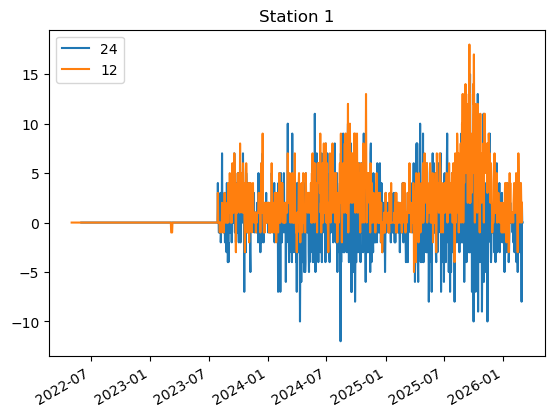

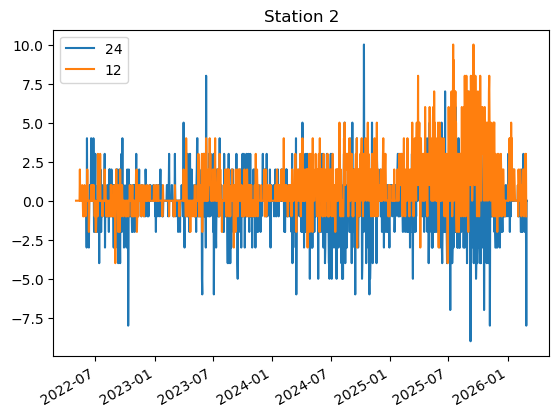

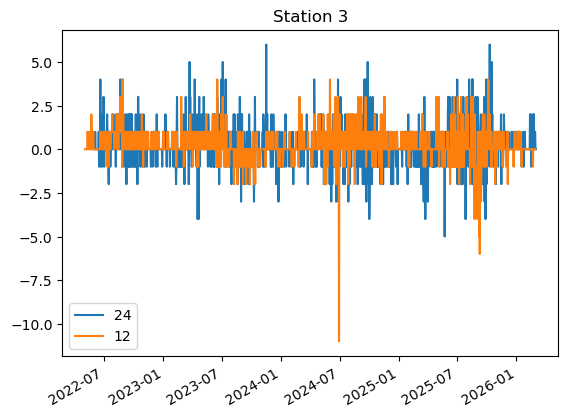

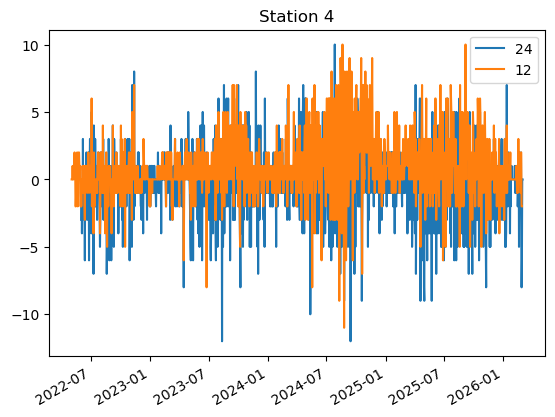

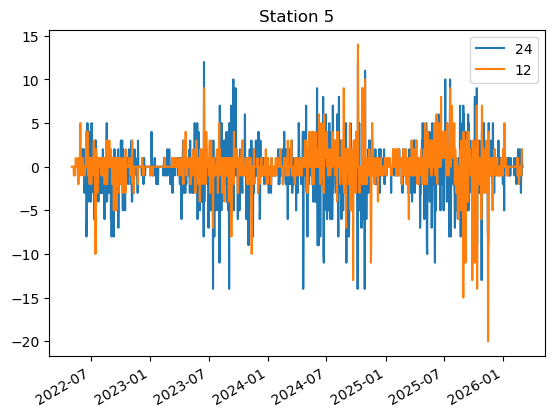

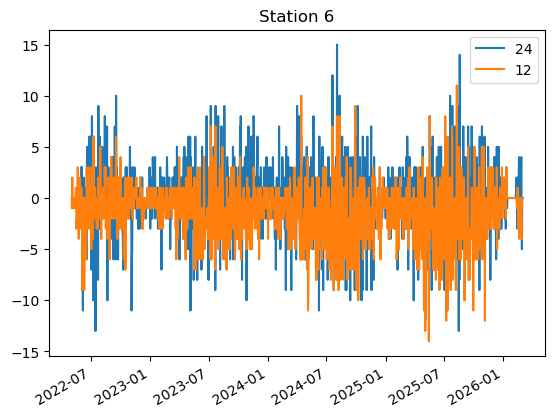

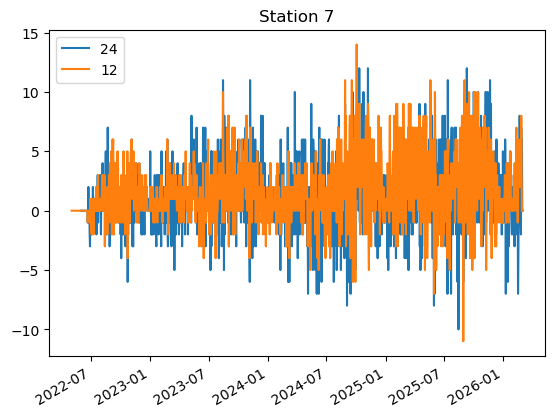

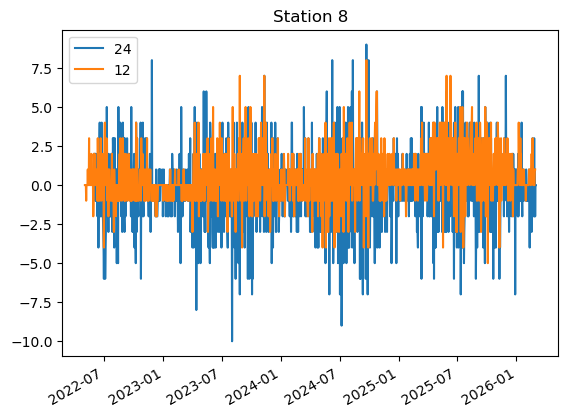

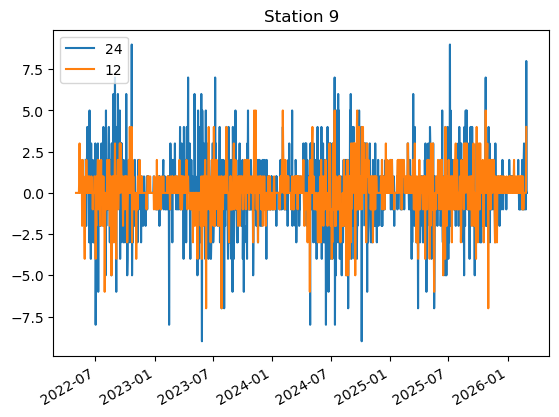

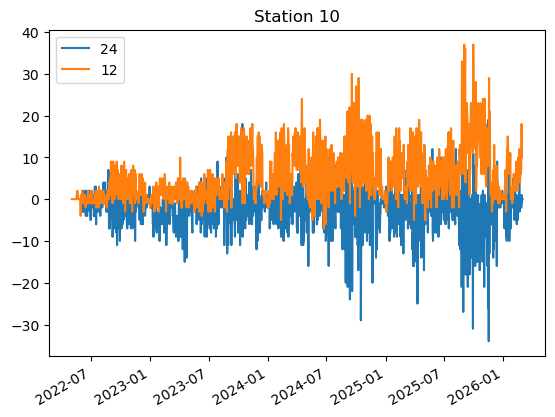

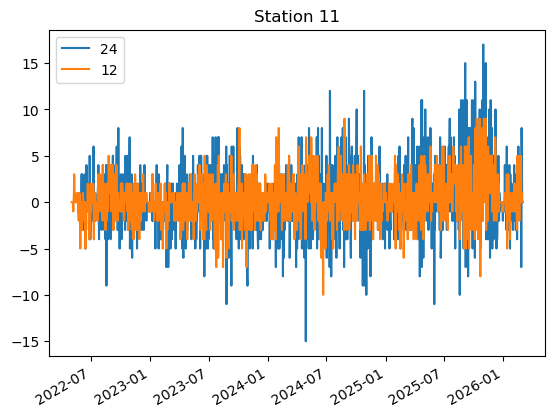

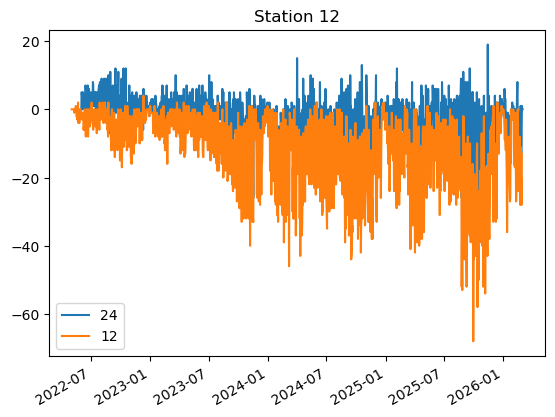

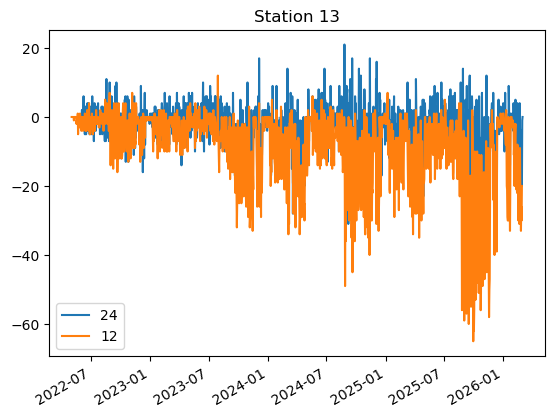

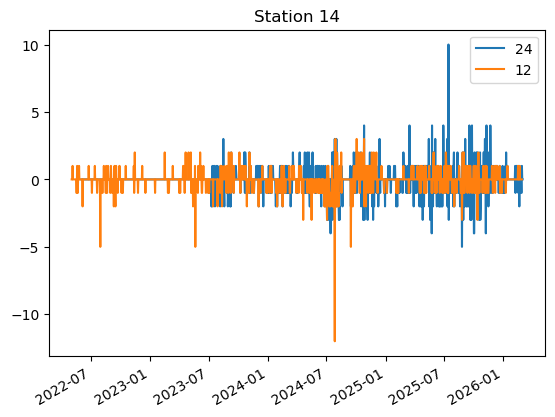

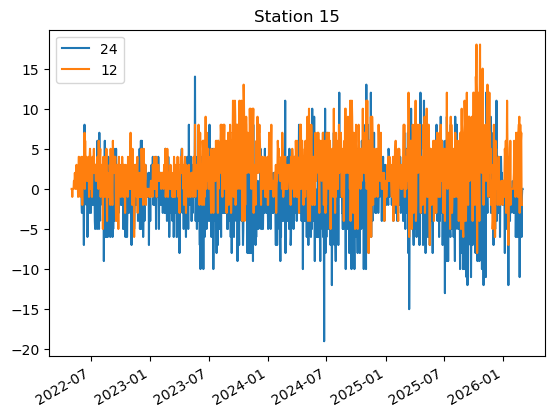

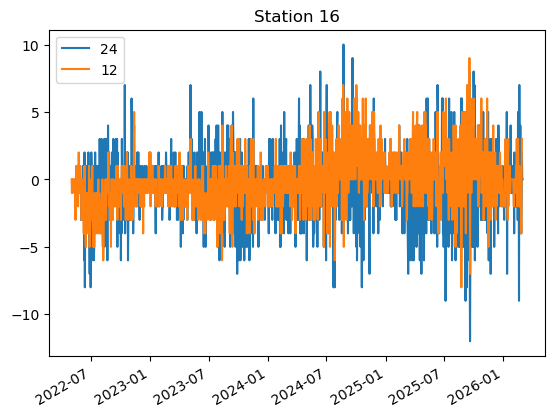

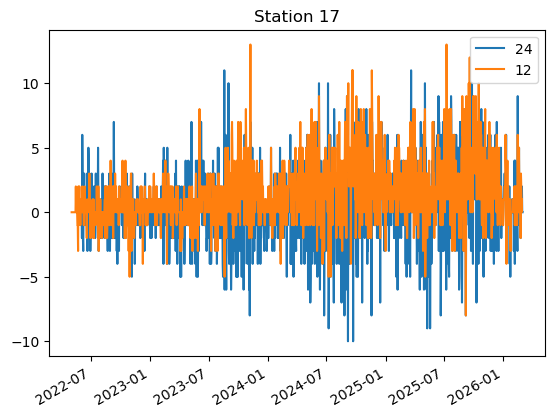

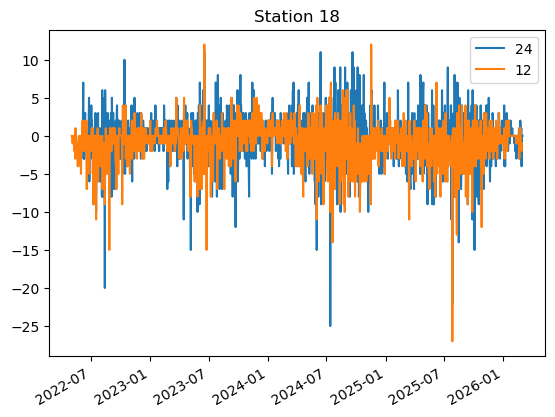

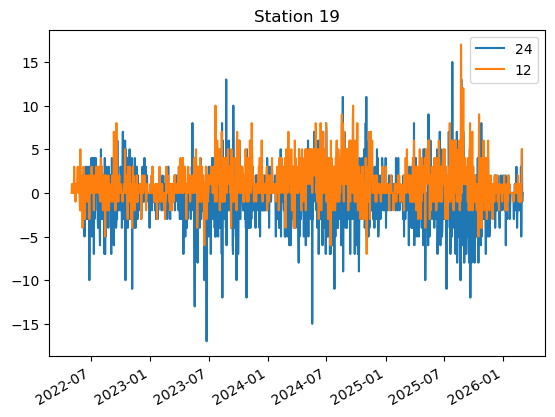

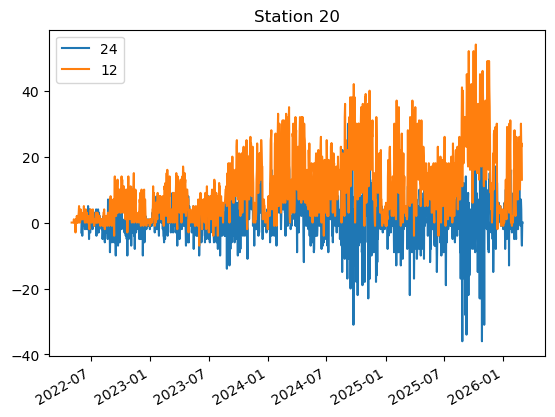

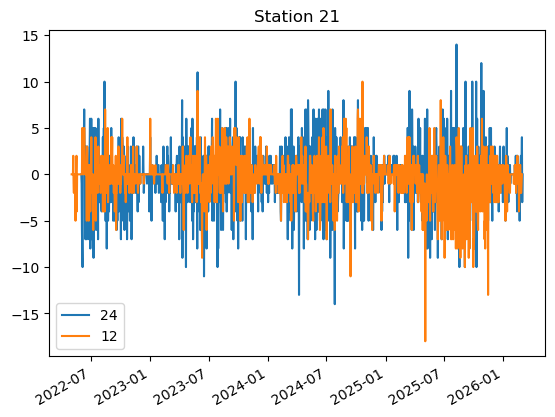

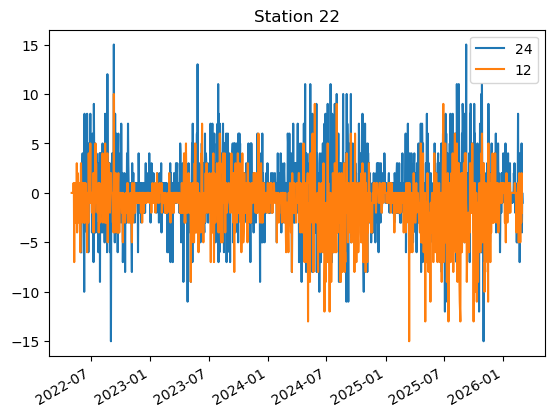

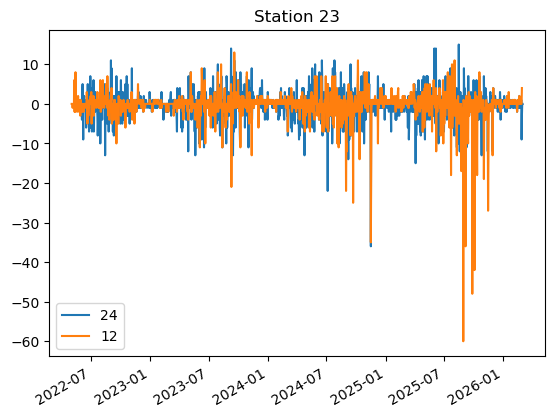

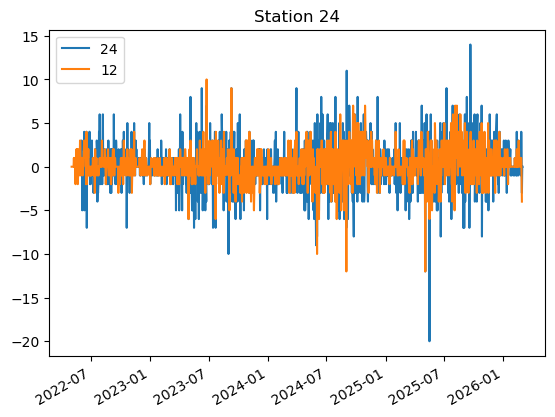

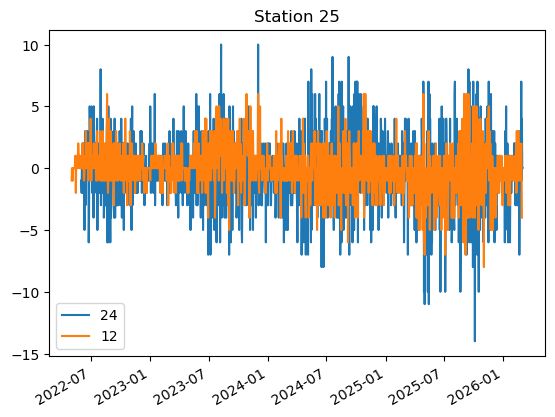

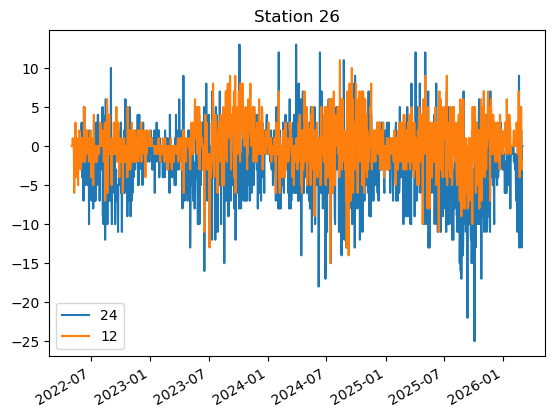

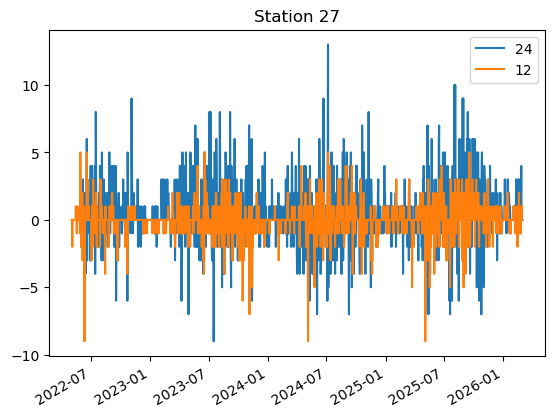

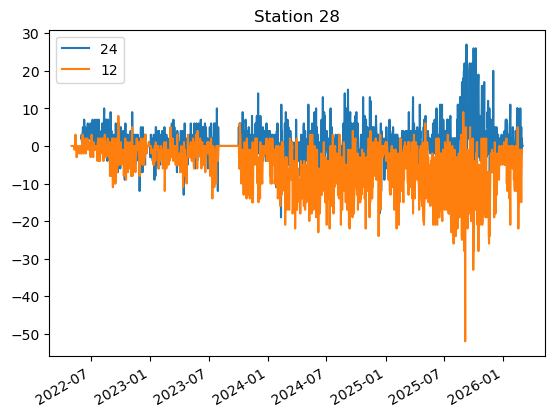

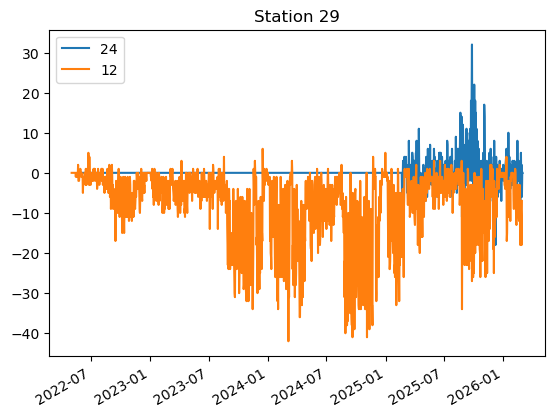

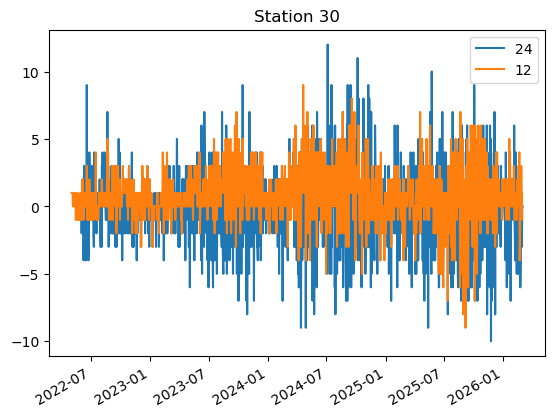

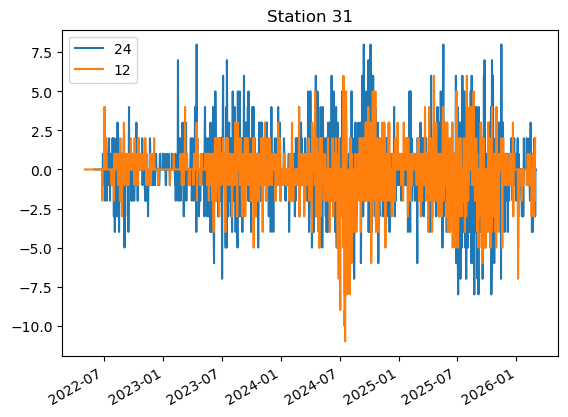

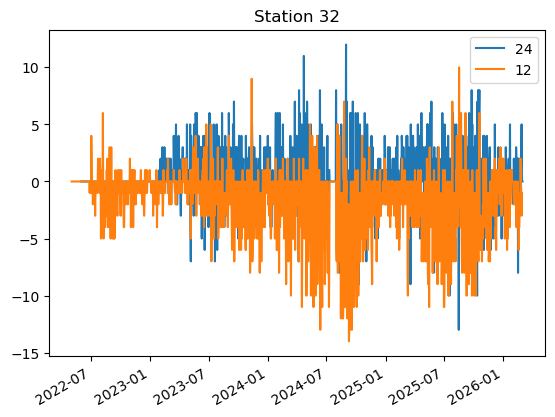

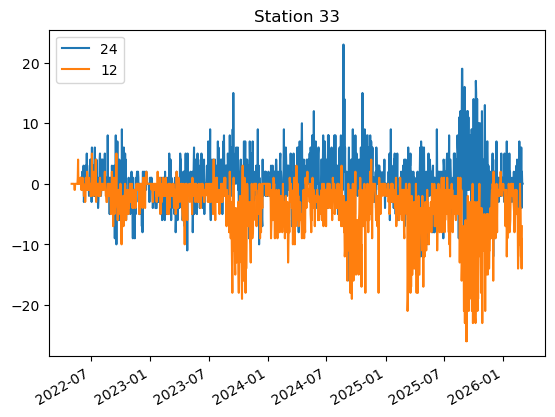

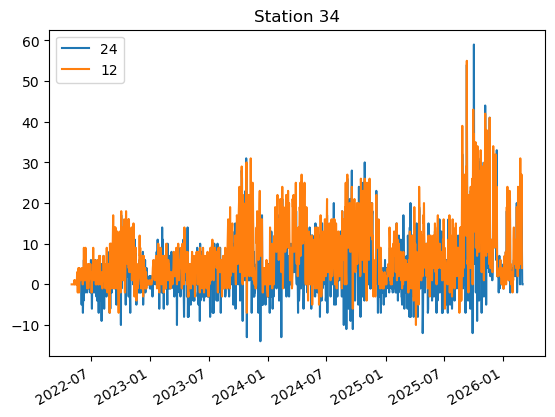

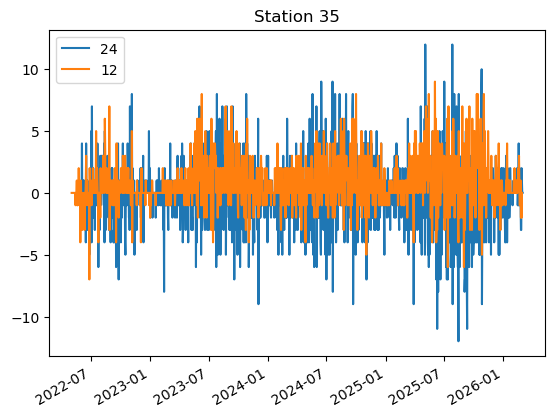

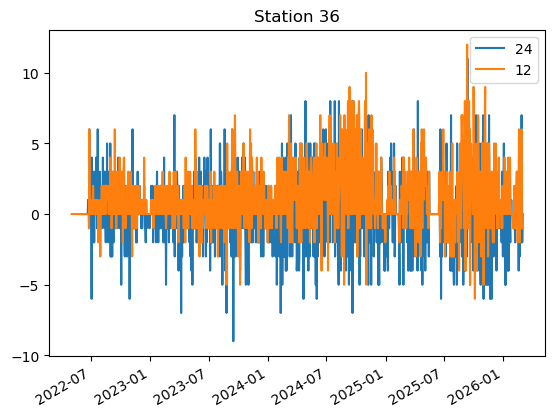

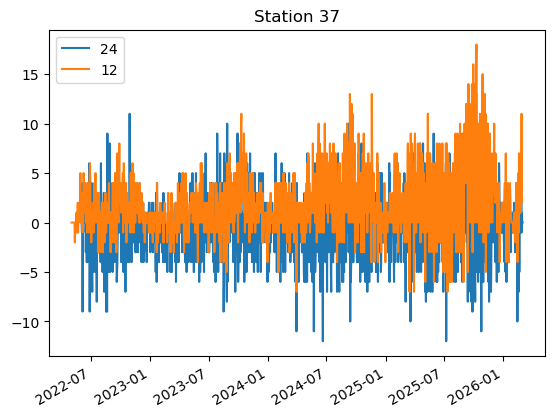

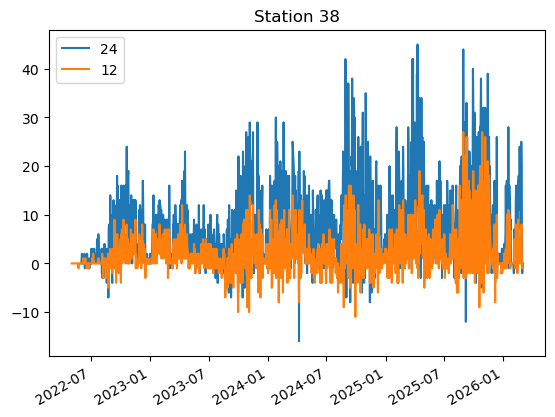

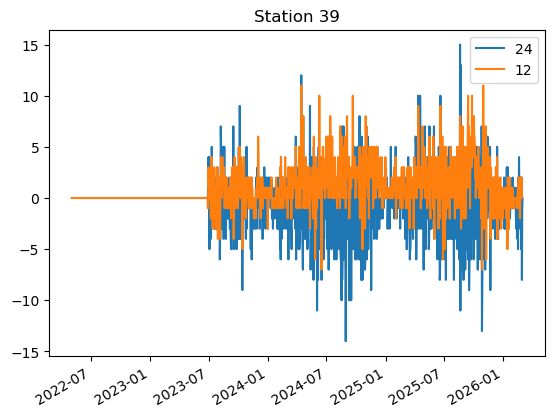

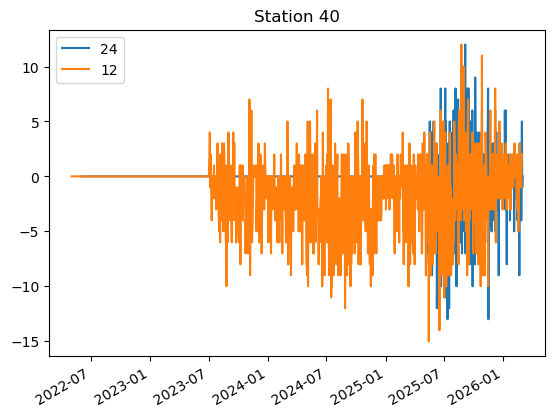

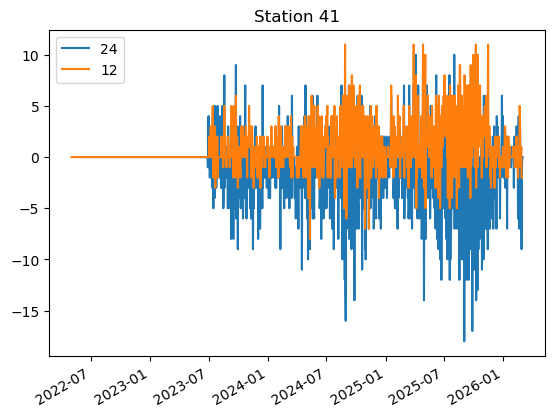

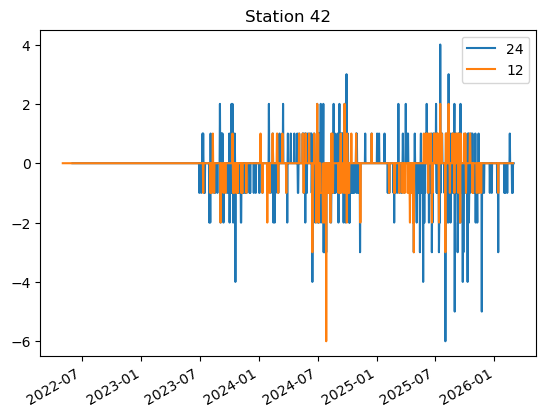

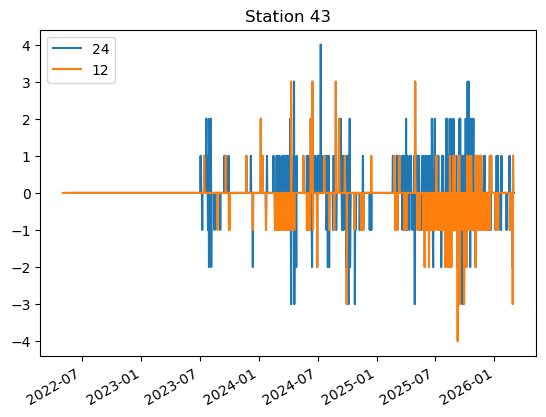

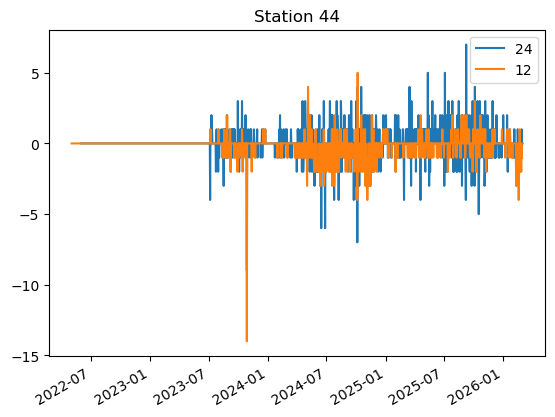

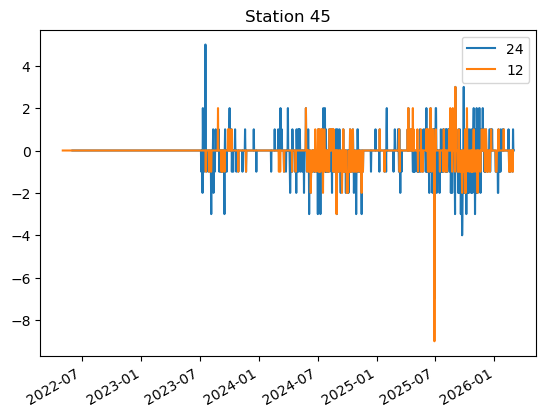

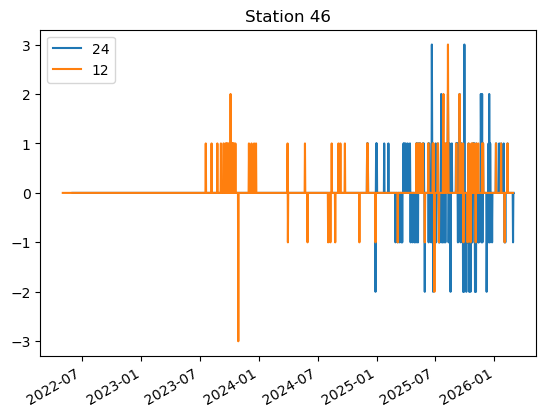

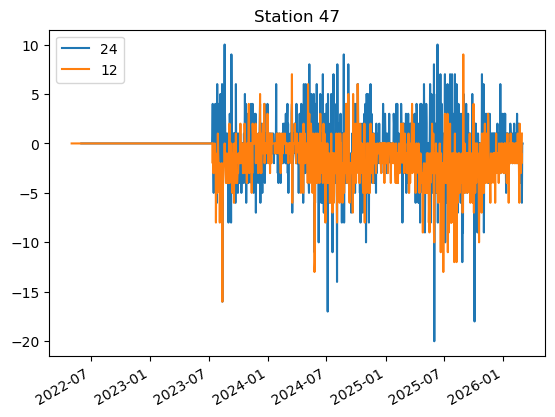

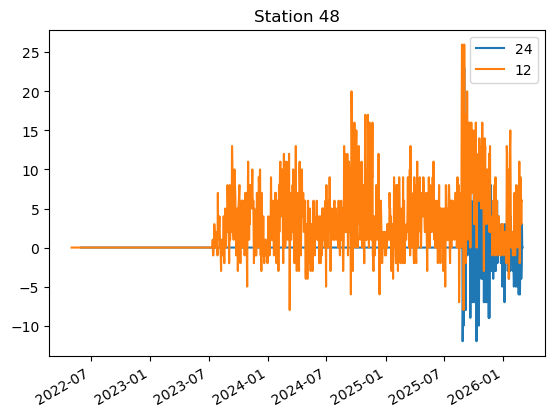

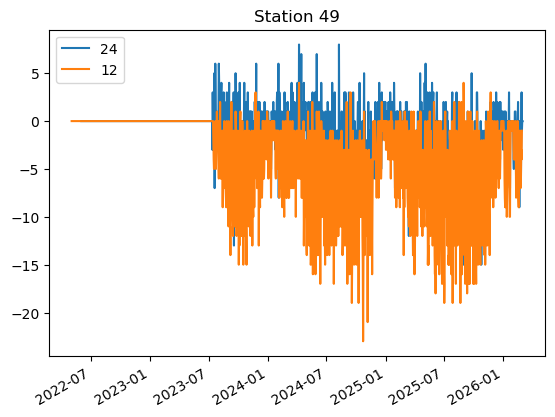

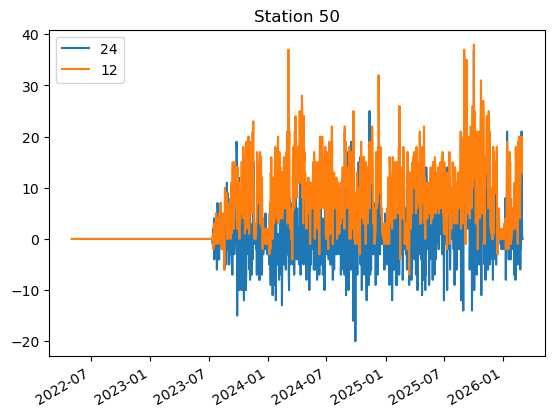

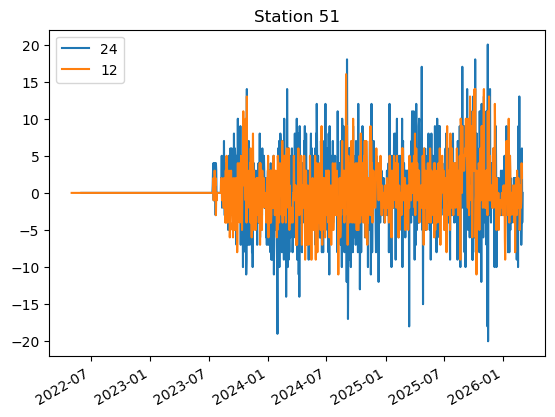

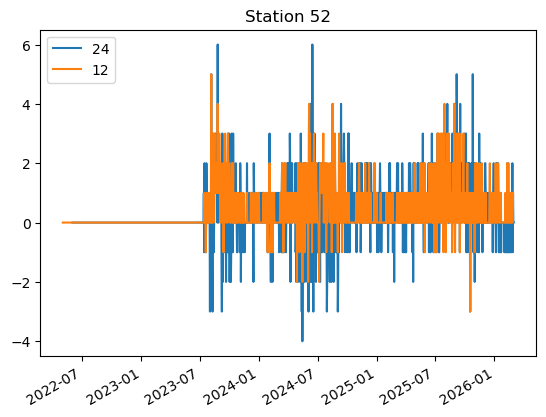

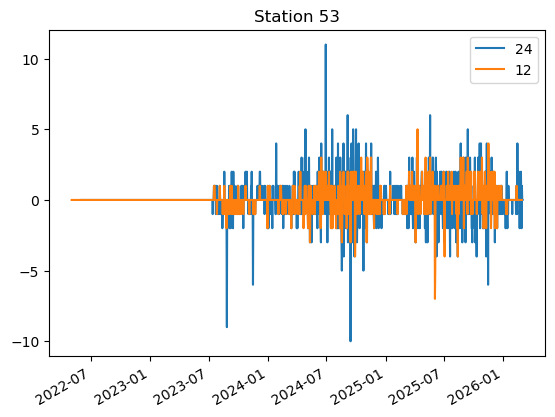

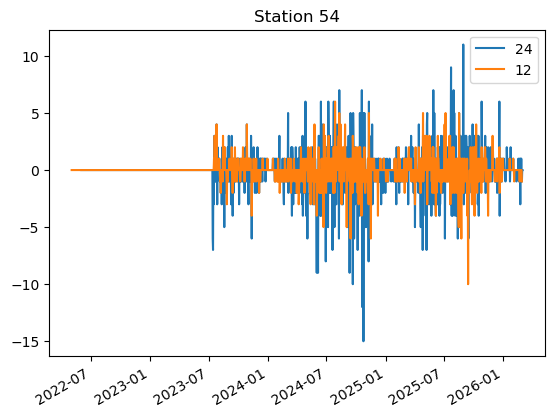

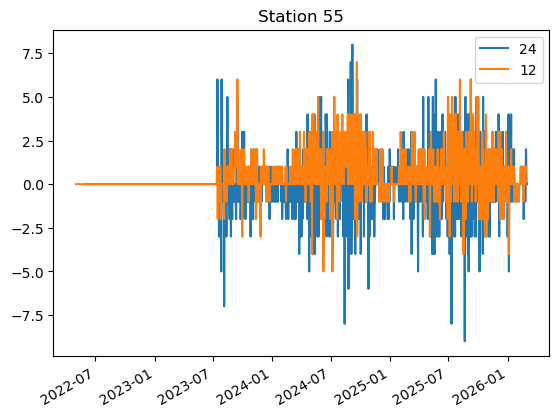

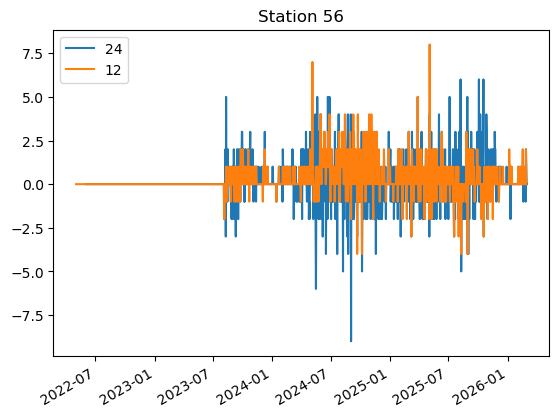

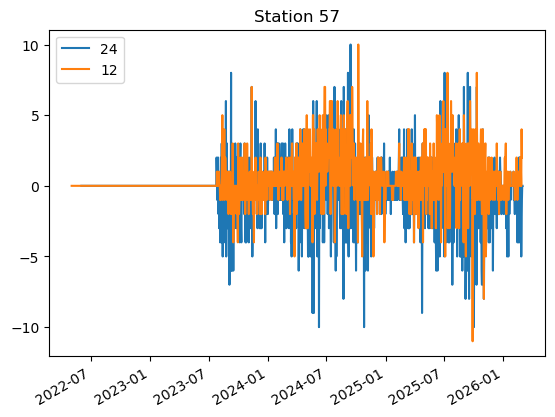

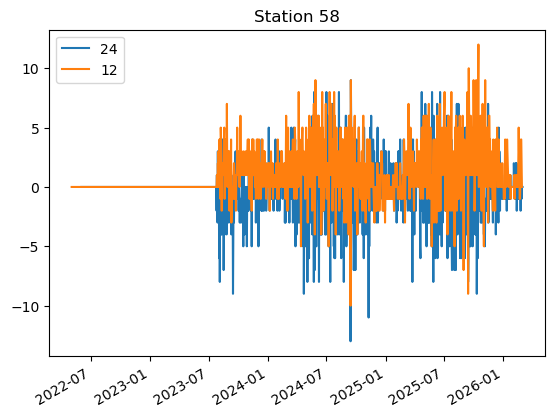

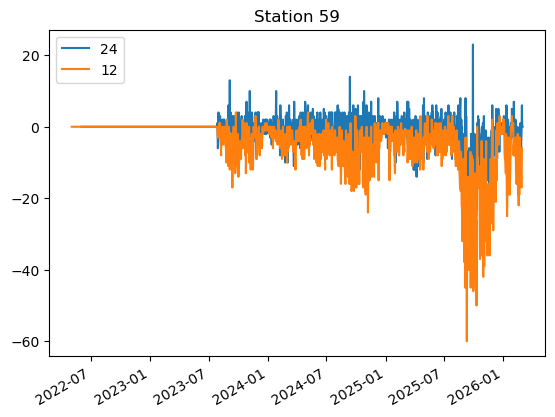

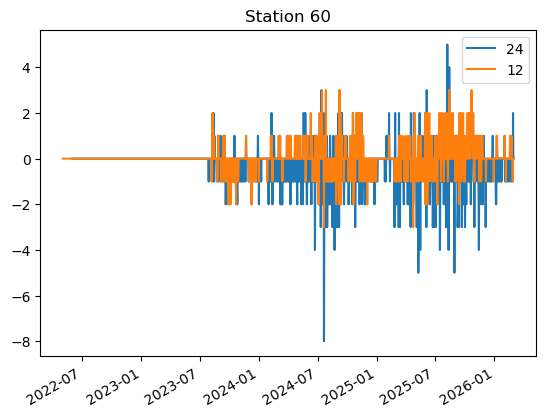

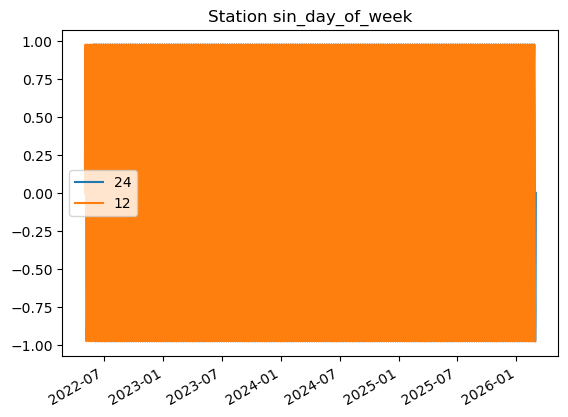

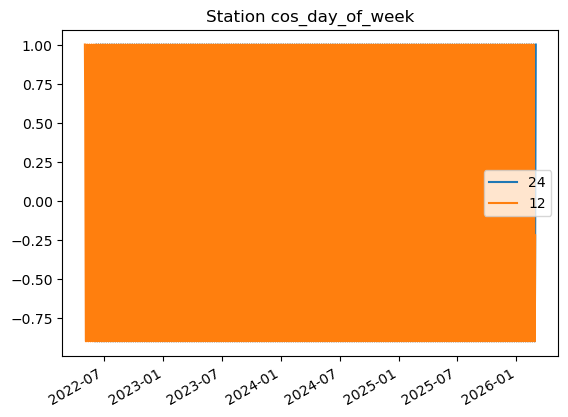

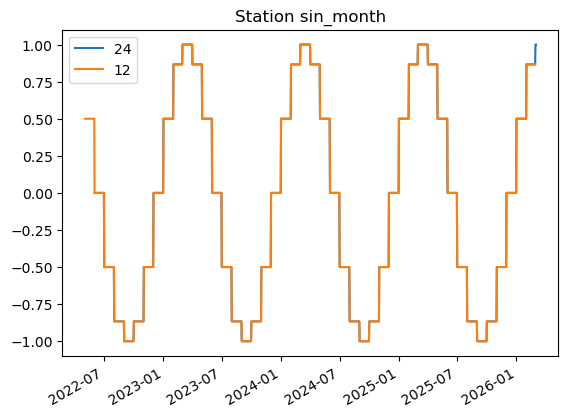

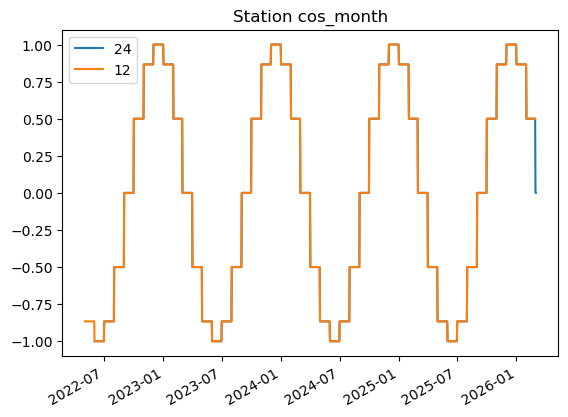

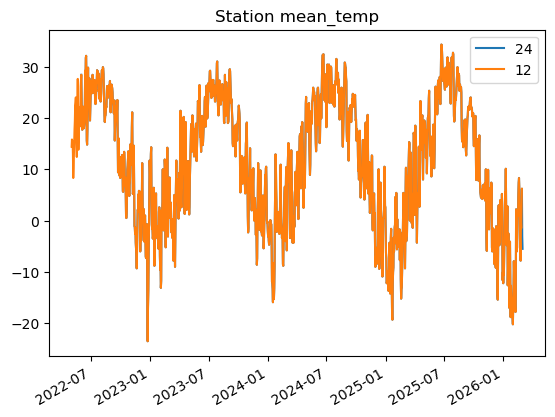

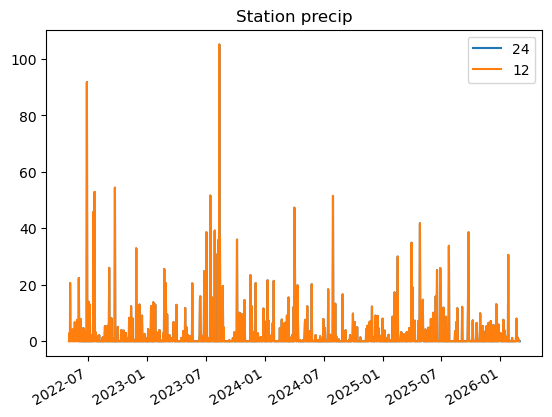

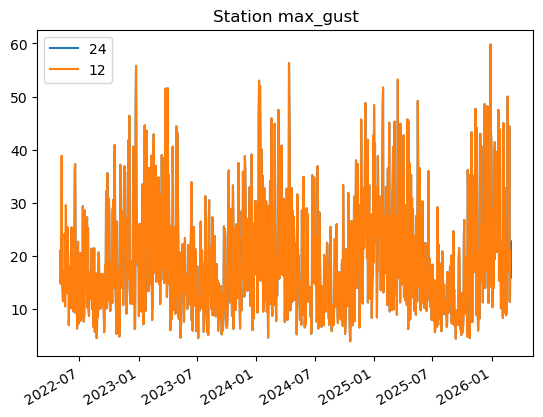

In [6]:
for col in df.columns:
    fig, ax = plt.subplots()
    ax.plot(df.index, df[col], label='24')
    ax.plot(df_12hr.index, df_12hr[col], label='12')

    fig.autofmt_xdate() 
    plt.legend()
    plt.title(f"Station {col}")
    plt.show()

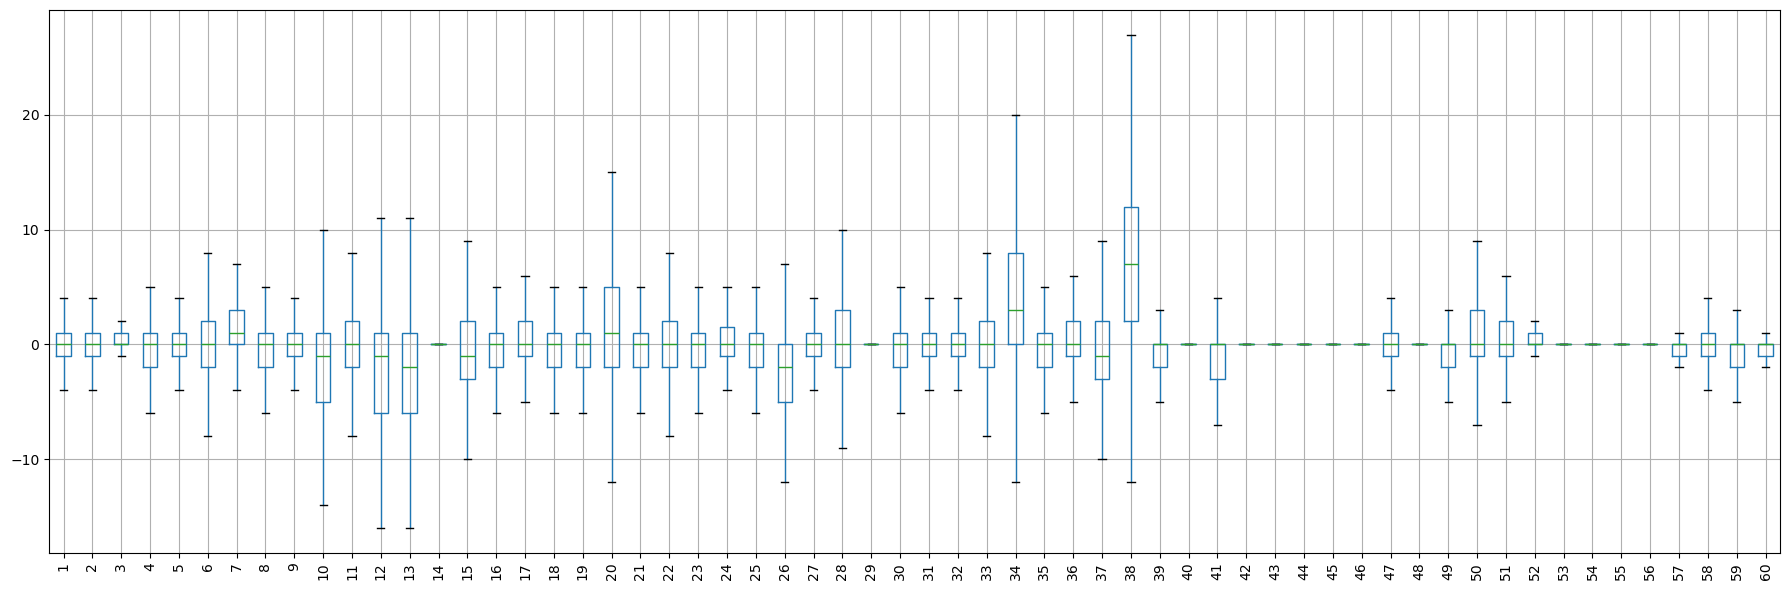

In [11]:
stations = df.columns[:-7]
# 1. Create a much wider figure (width: 18, height: 6)
plt.figure(figsize=(18, 6))

# 2. Plot the boxplot, hiding outliers
df[stations].boxplot(showfliers=False)

# 3. Rotate labels so they print vertically
plt.xticks(rotation=90)

# 4. Clean up the layout so labels aren't cut off
plt.tight_layout()
plt.show()

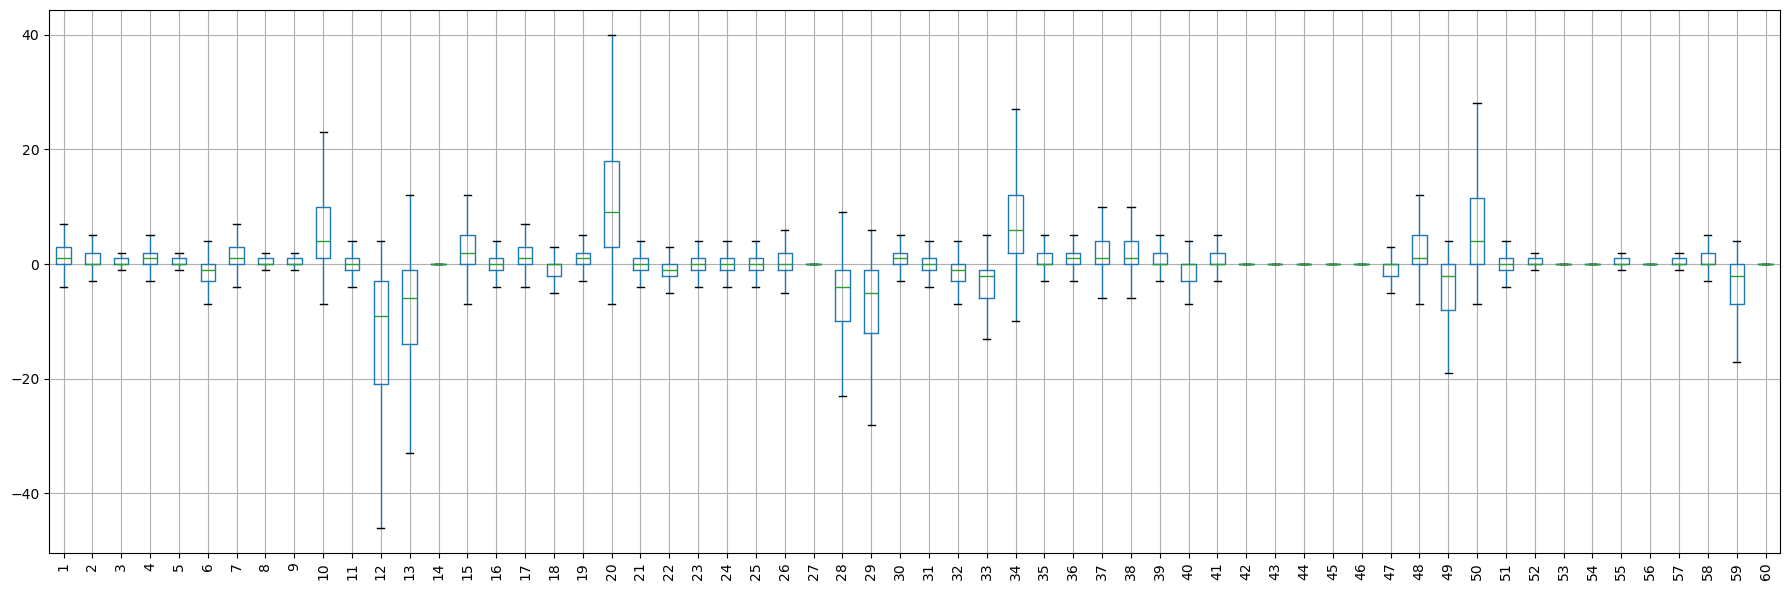

In [12]:
# 1. Create a much wider figure (width: 18, height: 6)
plt.figure(figsize=(18, 6))

# 2. Plot the boxplot, hiding outliers
df_12hr[stations].boxplot(showfliers=False)

# 3. Rotate labels so they print vertically
plt.xticks(rotation=90)

# 4. Clean up the layout so labels aren't cut off
plt.tight_layout()
plt.show()